# Kalman-Only Portfolio Replication

This notebook focuses only on Kalman-filter portfolio replication for the constructed target return series. The workflow is deliberately shorter than the previous multi-model notebook: load the data, define reusable risk and validation checks, initialize Kalman weights with a compact Elastic Net helper, then compare four Kalman variants.

The Kalman setup used throughout is:

- **Hidden state**: time-varying futures weights.
- **Observed scalar**: target return at each date.
- **Observed vector**: futures returns at that date.
- **State transition**: `A = I`, so weights follow a random walk.
- **Process noise**: diagonal `Q`, controlled by `process_noise`.
- **Observation noise**: scalar `R`, calibrated from target-return volatility.

Final selection is made only among Kalman filters, using validation tracking error first, then full OOS tracking error and turnover.


## 1) Imports and Configuration

This cell defines the data path, target/futures universe, risk limits, and compact grids used by the Kalman searches. The grids are intentionally small enough to keep the notebook fast while still testing initialization windows, process noise, observation noise, feature selection, and volatility regimes.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import make_scorer
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

FILE_PATH = r"D:\QuantProjects\Fintech\BusinessCase3\Dataset3_PortfolioReplicaStrategy.xlsx"
SHEET_NAME = "Copia_statica"

ANNUAL_FACTOR = 52
TRANSACTION_COST = 0.0005
MAX_GROSS_EXPOSURE = 2.0
MONTHLY_VAR_LIMIT = 0.20
VAR_CONFIDENCE = 0.01
VAR_HORIZON_WEEKS = 4

INDEX_COLUMNS = ["MXWO", "MXWD", "LEGATRUU", "HFRXGL"]
FUTURES_COLUMNS = ["RX1", "TY1", "GC1", "CO1", "ES1", "VG1", "NQ1", "LLL1", "TP1", "DU1", "TU2"]
TARGET_COMPONENTS = {"HFRXGL": 0.50, "MXWO": 0.25, "LEGATRUU": 0.25}

CV_SPLITS = 5
VALIDATION_FRACTION = 0.30
INITIAL_KALMAN_WINDOW = 156

KALMAN_INIT_WINDOW_GRID = [104, 130, 156, 208]
KALMAN_Q_GRID = [0.0005, 0.001, 0.0025, 0.005, 0.01]
KALMAN_R_GRID = [0.5, 1.0, 2.0, 4.0]

FEATURE_SELECTION_METHODS = ["corr", "stability", "enet_coef"]
KALMAN_TOP_K_GRID = [4, 5, 6, 8, None]
VOL_KALMAN_Q_GRID = [0.0005, 0.001, 0.0025]
VOL_KALMAN_R_GRID = [1.0, 2.0, 4.0]
STRESS_Q_MULT_GRID = [1.5, 2.0, 4.0]
STRESS_R_MULT_GRID = [0.75, 1.0, 1.5, 2.0]
VOL_WINDOW_GRID = [13, 26, 52]
VOL_QUANTILE_GRID = [0.65, 0.75, 0.85]


## 2) Load Data and Build Target

The target is a fixed blend of the index columns. Futures are kept at weekly frequency and aligned to the target dates. The data gate fails fast on duplicate dates, missing columns, all-NaN inputs, and near-constant futures before any model is fit.


Data rows: 705 | Return rows: 704 | Modeling rows: 704
Date range: 2007-10-23 to 2021-04-20


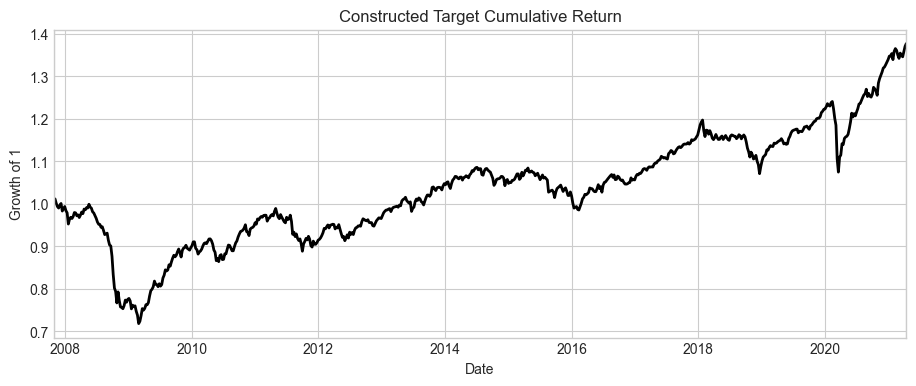

In [2]:
def run_data_gate_tests(df, expected_columns):
    issues = []
    if df.index.duplicated().any():
        issues.append(f"Duplicate dates: {int(df.index.duplicated().sum())}")
    missing = [c for c in expected_columns if c not in df.columns]
    if missing:
        issues.append(f"Missing columns: {missing}")
    all_nan = [c for c in expected_columns if c in df.columns and df[c].isna().all()]
    if all_nan:
        issues.append(f"All-NaN columns: {all_nan}")
    if issues:
        raise ValueError(" | ".join(issues))


data_raw = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME, header=0)
data_raw = data_raw.rename(columns={"Ticker": "Date"})
data_raw["Date"] = pd.to_datetime(data_raw["Date"])
data = data_raw.set_index("Date").sort_index()

expected_columns = INDEX_COLUMNS + FUTURES_COLUMNS
run_data_gate_tests(data, expected_columns)
data = data[expected_columns].apply(pd.to_numeric, errors="coerce")

returns_all = data.pct_change().dropna()
near_constant = returns_all[FUTURES_COLUMNS].std().loc[lambda s: s < 1e-10].index.tolist()
if near_constant:
    raise ValueError(f"Near-constant futures columns: {near_constant}")

component_returns = returns_all[list(TARGET_COMPONENTS.keys())]
target_returns = sum(component_returns[k] * v for k, v in TARGET_COMPONENTS.items())
target_returns.name = "Target_Index"

futures_returns = returns_all[FUTURES_COLUMNS]
common_dates = target_returns.index.intersection(futures_returns.index)
y = target_returns.loc[common_dates]
X = futures_returns.loc[common_dates]

assert X.index.equals(y.index), "Index/target misalignment after join."

print(f"Data rows: {len(data)} | Return rows: {len(returns_all)} | Modeling rows: {len(X)}")
print(f"Date range: {data.index.min().date()} to {data.index.max().date()}")

ax = (1 + y).cumprod().plot(figsize=(11, 4), color="black", linewidth=2)
ax.set_title("Constructed Target Cumulative Return")
ax.set_ylabel("Growth of 1")
plt.show()


## 3) Metrics, Risk Controls, and Validation Checks

These helpers are shared by every Kalman variant. They compute tracking error, correlation, drawdown, VaR, transaction costs, and accounting checks. The same reporting schema is used for every model so the final comparison is apples-to-apples.


In [3]:
def annualized_return(r):
    return float(pd.Series(r).mean() * ANNUAL_FACTOR)


def annualized_volatility(r):
    return float(pd.Series(r).std() * np.sqrt(ANNUAL_FACTOR))


def max_drawdown(returns):
    c = (1 + pd.Series(returns)).cumprod()
    dd = c / c.cummax() - 1
    return float(dd.min())


def tracking_error(replica, target):
    d = pd.Series(replica) - pd.Series(target)
    return float(d.std() * np.sqrt(ANNUAL_FACTOR))


def information_ratio(replica, target):
    te = tracking_error(replica, target)
    if te == 0 or np.isnan(te):
        return np.nan
    return float((pd.Series(replica) - pd.Series(target)).mean() * ANNUAL_FACTOR / te)


def estimated_var_1m(returns, confidence=VAR_CONFIDENCE, horizon=VAR_HORIZON_WEEKS):
    s = pd.Series(returns).dropna()
    if len(s) < 12:
        return 0.0
    z = stats.norm.ppf(confidence)
    return float(-z * s.std() * np.sqrt(horizon))


def count_var_breaches(returns):
    s = pd.Series(returns).dropna()
    if len(s) < 12:
        return 0
    weekly_var = estimated_var_1m(s) / np.sqrt(max(VAR_HORIZON_WEEKS, 1))
    return int((s < -weekly_var).sum())


def scale_weights_for_risk(weights, hist_X):
    w = pd.Series(weights, index=hist_X.columns).fillna(0.0).astype(float)
    gross = float(w.abs().sum())
    if gross == 0:
        return w, 1.0, 0.0, 0.0
    hist_port = hist_X.dot(w)
    var_est = estimated_var_1m(hist_port)
    gross_scale = min(1.0, MAX_GROSS_EXPOSURE / gross)
    var_scale = min(1.0, MONTHLY_VAR_LIMIT / var_est) if var_est > 0 else 1.0
    scale = min(gross_scale, var_scale)
    ws = w * scale
    return ws, scale, float(ws.abs().sum()), estimated_var_1m(hist_X.dot(ws))


def metrics_table(replica, target, weights=None, turnover=None, costs=None, label="model"):
    a = pd.concat([pd.Series(replica, name="Replica"), pd.Series(target, name="Target")], axis=1).dropna()
    rep = a["Replica"]
    tar = a["Target"]
    out = {
        "Model": label,
        "Obs": len(a),
        "Replica Return": annualized_return(rep),
        "Replica Vol": annualized_volatility(rep),
        "Tracking Error": tracking_error(rep, tar),
        "Information Ratio": information_ratio(rep, tar),
        "Correlation": float(rep.corr(tar)),
        "Replica Max Drawdown": max_drawdown(rep),
        "Target Max Drawdown": max_drawdown(tar),
        "Estimated 1M VaR": estimated_var_1m(rep),
        "VaR Breaches": count_var_breaches(rep),
    }
    if weights is not None:
        out["Average Gross Exposure"] = float(weights.abs().sum(axis=1).mean())
    if turnover is not None:
        out["Average Turnover"] = float(pd.Series(turnover).mean())
    if costs is not None:
        out["Total Transaction Cost"] = float(pd.Series(costs).sum())
    return out


def validate_no_lookahead(train_end_series, pred_dates):
    bad = train_end_series >= pred_dates
    if bool(bad.any()):
        raise AssertionError("No-lookahead check failed: train window reaches prediction timestamp.")


def validate_accounting(net, gross, costs, weights, turnover, rebalance_flags, cost_rate):
    if not np.allclose((gross - costs).values, net.values, atol=1e-12):
        raise AssertionError("Accounting check failed: net != gross - cost")
    implied = (weights - weights.shift(1).fillna(0.0)).abs().sum(axis=1)
    rb = pd.Series(rebalance_flags, index=weights.index)
    if rb.any():
        if not np.allclose(implied[rb].values, pd.Series(turnover, index=weights.index)[rb].values, atol=1e-8):
            raise AssertionError("Accounting check failed: turnover mismatch on rebalance dates")
    expected_cost = cost_rate * pd.Series(turnover, index=weights.index)
    if not np.allclose(expected_cost.values, pd.Series(costs, index=weights.index).values, atol=1e-12):
        raise AssertionError("Accounting check failed: cost != rate * turnover")


def validate_final_summary_columns(df):
    required = [
        "Tracking Error", "Correlation", "Information Ratio",
        "Average Turnover", "Average Gross Exposure",
        "Estimated 1M VaR", "VaR Breaches",
        "Replica Max Drawdown", "Target Max Drawdown",
    ]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise AssertionError(f"Missing required final columns: {missing}")
    na_cols = [c for c in required if df[c].isna().any()]
    if na_cols:
        raise AssertionError(f"Final summary has NaN values in required columns: {na_cols}")
    print("Reporting completeness test passed.")


def validation_tracking_error(details, validation_fraction=VALIDATION_FRACTION):
    aligned = pd.concat([details["replica"].rename("Replica"), details["target"].rename("Target")], axis=1).dropna()
    if len(aligned) < 30:
        return np.inf
    start = int(len(aligned) * (1 - validation_fraction))
    sub = aligned.iloc[start:]
    return tracking_error(sub["Replica"], sub["Target"])


## 4) Kalman Initialization and Feature Selection

Elastic Net is retained only as a helper: it provides stable initial weights for the Kalman state and one optional feature-selection score. It is not reported as a standalone benchmark. Feature selection is always based on data available before the first Kalman prediction.


In [4]:
def fit_enet_raw_weights(X_train, y_train, alpha, l1_ratio):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X_train)
    model = ElasticNet(alpha=float(alpha), l1_ratio=float(l1_ratio), max_iter=50000)
    model.fit(Xs, y_train.values)
    return pd.Series(model.coef_ / scaler.scale_, index=X_train.columns)


def cv_tracking_error(y_true, y_pred):
    d = np.asarray(y_pred) - np.asarray(y_true)
    return float(np.std(d, ddof=1)) if len(d) > 1 else np.inf


def tune_enet_initializer(X_train, y_train):
    cv = TimeSeriesSplit(n_splits=CV_SPLITS)
    scorer = make_scorer(cv_tracking_error, greater_is_better=False)
    grid = {
        "alpha": [1e-5, 3e-5, 1e-4, 3e-4, 1e-3],
        "l1_ratio": [0.05, 0.15, 0.30, 0.50, 0.70],
    }
    search = GridSearchCV(ElasticNet(max_iter=50000), grid, cv=cv, scoring=scorer, n_jobs=-1)
    search.fit(X_train, y_train)
    return {
        "alpha": float(search.best_params_["alpha"]),
        "l1_ratio": float(search.best_params_["l1_ratio"]),
        "CV Tracking Error": float(-search.best_score_),
    }


enet_best_spec = tune_enet_initializer(X.iloc[:INITIAL_KALMAN_WINDOW], y.iloc[:INITIAL_KALMAN_WINDOW])
print("Elastic Net initializer parameters:", enet_best_spec)


def initialize_kalman_from_enet(X_init, y_init, alpha=None, l1_ratio=None):
    alpha = enet_best_spec["alpha"] if alpha is None else alpha
    l1_ratio = enet_best_spec["l1_ratio"] if l1_ratio is None else l1_ratio
    raw_w = fit_enet_raw_weights(X_init, y_init, alpha=alpha, l1_ratio=l1_ratio)
    w0, _, _, _ = scale_weights_for_risk(raw_w, X_init)
    return w0


def select_kalman_features(X_train, y_train, method="corr", top_k=6, rolling_window=26):
    if top_k is None or int(top_k) >= X_train.shape[1]:
        return list(X_train.columns)

    top_k = max(1, int(top_k))
    aligned = pd.concat([pd.Series(y_train, name="Target"), X_train], axis=1).dropna()
    y_a = aligned["Target"]
    X_a = aligned[X_train.columns]

    if method == "corr":
        scores = X_a.corrwith(y_a).abs().replace([np.inf, -np.inf], np.nan).fillna(0.0)
    elif method == "stability":
        rw = min(int(rolling_window), max(8, len(X_a) // 3))
        scores = pd.Series({
            col: (lambda rc: 0.0 if len(rc) == 0 else float(rc.mean() - 0.50 * rc.std(ddof=0)))(
                X_a[col].rolling(rw).corr(y_a).dropna().abs()
            )
            for col in X_a.columns
        })
    elif method == "enet_coef":
        scores = fit_enet_raw_weights(X_train, y_train, enet_best_spec["alpha"], enet_best_spec["l1_ratio"]).abs()
    else:
        raise ValueError(f"Unknown feature-selection method: {method}")

    selected = scores.sort_values(ascending=False).head(top_k).index.tolist()
    return selected if selected else list(X_train.columns)


def ensure_psd(matrix, eps=1e-10):
    matrix = 0.5 * (matrix + matrix.T)
    eigvals, eigvecs = np.linalg.eigh(matrix)
    eigvals = np.clip(eigvals, eps, None)
    return eigvecs @ np.diag(eigvals) @ eigvecs.T


def target_vol_regime(y_hist, vol_window, vol_quantile):
    if len(y_hist) < max(vol_window, 8):
        return "calm", np.nan, np.nan
    rolling_vol = y_hist.rolling(vol_window).std().dropna()
    if len(rolling_vol) == 0:
        return "calm", np.nan, np.nan
    current_vol = float(y_hist.iloc[-vol_window:].std())
    threshold = float(rolling_vol.quantile(vol_quantile))
    regime = "stress" if np.isfinite(current_vol) and current_vol > threshold else "calm"
    return regime, current_vol, threshold


Elastic Net initializer parameters: {'alpha': 0.0001, 'l1_ratio': 0.05, 'CV Tracking Error': 0.0053378911946814055}


## 5) Shared Kalman Backtest Engine

All four variants use the same engine. Variant behavior is controlled by feature selection, Huber innovation clipping, and volatility-regime noise multipliers. The engine records train-end dates, turnover, costs, selected futures, and volatility regimes so each model can be audited consistently.


In [5]:
def backtest_kalman_variant(
    X, y,
    label="Kalman",
    init_window=INITIAL_KALMAN_WINDOW,
    process_noise=0.001,
    obs_noise_scale=2.0,
    feature_method=None,
    top_k=None,
    huber_k=None,
    vol_aware=False,
    stress_q_mult=1.0,
    stress_r_mult=1.0,
    vol_window=26,
    vol_quantile=0.75,
    transaction_cost=TRANSACTION_COST,
):
    X_init = X.iloc[:init_window]
    y_init = y.iloc[:init_window]
    selected = select_kalman_features(X_init, y_init, feature_method, top_k, vol_window) if feature_method else list(X.columns)
    X_sel = X[selected]

    n_assets = len(selected)
    A = np.eye(n_assets)
    Q_base = np.eye(n_assets) * (process_noise ** 2)
    R_base = max(float((obs_noise_scale * y_init.std()) ** 2), 1e-10)

    w0 = initialize_kalman_from_enet(X_sel.iloc[:init_window], y_init)
    assert len(w0) == n_assets, "Kalman initial state dimension mismatch."

    w = w0.values.reshape(-1, 1)
    P = np.eye(n_assets) * 0.25
    prev_trade_w = pd.Series(0.0, index=X.columns)

    dates, rep, gross, tar, w_list, turn, cost, train_end, reb = [], [], [], [], [], [], [], [], []
    regimes, current_vols, vol_thresholds = [], [], []

    for t in range(init_window, len(X)):
        if vol_aware:
            regime, current_vol, threshold = target_vol_regime(y.iloc[:t], vol_window, vol_quantile)
        else:
            regime, current_vol, threshold = "all", np.nan, np.nan

        stress = regime == "stress"
        Q = Q_base * (stress_q_mult if stress else 1.0)
        R = R_base * (stress_r_mult if stress else 1.0)

        C_t = X_sel.iloc[t].values.reshape(1, -1)
        w_pred = A @ w
        P_pred = ensure_psd(A @ P @ A.T + Q)

        raw_trade_w = pd.Series(w_pred.flatten(), index=selected)
        trade_w_sel, _, _, _ = scale_weights_for_risk(raw_trade_w, X_sel.iloc[:t])
        trade_w = pd.Series(0.0, index=X.columns)
        trade_w.loc[selected] = trade_w_sel

        turnover = float((trade_w - prev_trade_w).abs().sum())
        c = transaction_cost * turnover
        g = float(X.iloc[t].dot(trade_w))
        r = float(g - c)

        y_pred = float((C_t @ w_pred).item())
        innovation = float(y.iloc[t] - y_pred)
        S = max(float((C_t @ P_pred @ C_t.T + R).item()), 1e-10)
        if huber_k is not None:
            innovation = float(np.clip(innovation, -huber_k * np.sqrt(S), huber_k * np.sqrt(S)))

        K = (P_pred @ C_t.T) / S
        w = w_pred + K * innovation
        I = np.eye(n_assets)
        P = ensure_psd((I - K @ C_t) @ P_pred @ (I - K @ C_t).T + K * R * K.T)

        dates.append(X.index[t]); rep.append(r); gross.append(g); tar.append(float(y.iloc[t]))
        w_list.append(trade_w.copy()); turn.append(turnover); cost.append(c)
        train_end.append(X.index[t - 1]); reb.append(True); prev_trade_w = trade_w
        regimes.append(regime); current_vols.append(current_vol); vol_thresholds.append(threshold)

    rep_s = pd.Series(rep, index=dates, name="Replica")
    gross_s = pd.Series(gross, index=dates, name="Gross_Replica")
    tar_s = pd.Series(tar, index=dates, name="Target")
    w_df = pd.DataFrame(w_list, index=dates, columns=X.columns)
    turn_s = pd.Series(turn, index=dates, name="Turnover")
    cost_s = pd.Series(cost, index=dates, name="Cost")
    train_s = pd.Series(train_end, index=dates, name="Train_End")
    reb_s = pd.Series(reb, index=dates, name="Rebalance")

    validate_no_lookahead(train_s, pd.Series(dates, index=dates))
    validate_accounting(rep_s, gross_s, cost_s, w_df, turn_s, reb_s, transaction_cost)

    result = metrics_table(rep_s, tar_s, weights=w_df, turnover=turn_s, costs=cost_s, label=label)
    details = {
        "replica": rep_s, "gross": gross_s, "target": tar_s, "weights": w_df,
        "turnover": turn_s, "costs": cost_s, "train_end": train_s, "rebalance": reb_s,
        "selected_features": selected,
        "vol_regime": pd.Series(regimes, index=dates, name="Vol_Regime"),
        "target_rolling_vol": pd.Series(current_vols, index=dates, name="Target_Rolling_Vol"),
        "vol_threshold": pd.Series(vol_thresholds, index=dates, name="Vol_Threshold"),
    }
    return result, details


def run_spec_search(specs, label):
    rows, payloads = [], {}
    best = {"Validation TE": np.inf, "Full OOS TE": np.inf, "Average Turnover": np.inf}
    for i, spec in enumerate(specs):
        if spec["init_window"] >= len(X) - 20:
            continue
        result, details = backtest_kalman_variant(X, y, label=label, **spec)
        vte = validation_tracking_error(details)
        key = f"{label}_{i:03d}"
        row = {
            "Key": key,
            **spec,
            "Selected Futures": ", ".join(details["selected_features"]),
            "Stress Obs": int((details["vol_regime"] == "stress").sum()),
            "Validation TE": float(vte),
            "Full OOS TE": float(result["Tracking Error"]),
            "Average Turnover": float(result["Average Turnover"]),
        }
        rows.append(row)
        payloads[key] = (result, details)
        if (row["Validation TE"], row["Full OOS TE"], row["Average Turnover"]) < (best["Validation TE"], best["Full OOS TE"], best["Average Turnover"]):
            best = {**row, "result": result, "details": details}

    search_df = pd.DataFrame(rows).sort_values(["Validation TE", "Full OOS TE", "Average Turnover"]).reset_index(drop=True)
    if search_df.empty:
        raise RuntimeError(f"No valid specs for {label}.")
    return search_df, best, payloads


def compact_grid(specs, max_specs):
    if len(specs) <= max_specs:
        return specs
    idx = np.linspace(0, len(specs) - 1, max_specs, dtype=int)
    return [specs[i] for i in idx]


## 6) Baseline Kalman Filter

The baseline Kalman filter uses the full futures universe. It estimates time-varying weights with `A = I`, diagonal process noise, scalar observation noise, Joseph-form covariance updates, and the same risk scaling used by all other variants.


In [6]:
baseline_specs = [
    {"init_window": iw, "process_noise": q, "obs_noise_scale": r}
    for iw in KALMAN_INIT_WINDOW_GRID
    for q in KALMAN_Q_GRID
    for r in KALMAN_R_GRID
]

baseline_kalman_search_df, _baseline_best, baseline_kalman_payloads = run_spec_search(baseline_specs, "Baseline Kalman")
baseline_kalman_result = _baseline_best["result"]
baseline_kalman_details = _baseline_best["details"]
baseline_kalman_best_spec = {k: _baseline_best[k] for k in ["init_window", "process_noise", "obs_noise_scale"]}

print("Best baseline Kalman spec:", baseline_kalman_best_spec)
display(baseline_kalman_search_df.head(10))
display(pd.DataFrame([baseline_kalman_result]))


Best baseline Kalman spec: {'init_window': 104, 'process_noise': 0.0005, 'obs_noise_scale': 2.0}


,Key,init_window,process_noise,obs_noise_scale,Selected Futures,Stress Obs,Validation TE,Full OOS TE,Average Turnover
0,Baseline Kalman_002,104,0.0005,2.0000,"RX1, TY1, GC1, CO1, ES1, VG1, NQ1, LLL1, TP1, ...",0,0.0339,0.0275,0.0119
1,Baseline Kalman_003,104,0.0005,4.0000,"RX1, TY1, GC1, CO1, ES1, VG1, NQ1, LLL1, TP1, ...",0,0.0339,0.0276,0.0076
2,Baseline Kalman_007,104,0.0010,4.0000,"RX1, TY1, GC1, CO1, ES1, VG1, NQ1, LLL1, TP1, ...",0,0.0339,0.0276,0.0076
3,Baseline Kalman_006,104,0.0010,2.0000,"RX1, TY1, GC1, CO1, ES1, VG1, NQ1, LLL1, TP1, ...",0,0.0339,0.0275,0.0119
4,Baseline Kalman_011,104,0.0025,4.0000,"RX1, TY1, GC1, CO1, ES1, VG1, NQ1, LLL1, TP1, ...",0,0.0340,0.0276,0.0076
5,Baseline Kalman_001,104,0.0005,1.0000,"RX1, TY1, GC1, CO1, ES1, VG1, NQ1, LLL1, TP1, ...",0,0.0341,0.0277,0.0185
6,Baseline Kalman_010,104,0.0025,2.0000,"RX1, TY1, GC1, CO1, ES1, VG1, NQ1, LLL1, TP1, ...",0,0.0343,0.0276,0.0121
7,Baseline Kalman_005,104,0.0010,1.0000,"RX1, TY1, GC1, CO1, ES1, VG1, NQ1, LLL1, TP1, ...",0,0.0343,0.0278,0.0186
8,Baseline Kalman_015,104,0.0050,4.0000,"RX1, TY1, GC1, CO1, ES1, VG1, NQ1, LLL1, TP1, ...",0,0.0343,0.0276,0.0078
9,Baseline Kalman_042,156,0.0005,2.0000,"RX1, TY1, GC1, CO1, ES1, VG1, NQ1, LLL1, TP1, ...",0,0.0343,0.0274,0.0128


,Model,Obs,Replica Return,Replica Vol,Tracking Error,Information Ratio,Correlation,Replica Max Drawdown,Target Max Drawdown,Estimated 1M VaR,VaR Breaches,Average Gross Exposure,Average Turnover,Total Transaction Cost
0,Baseline Kalman,600,0.0374,0.0496,0.0275,-0.0609,0.8716,-0.0952,-0.1339,0.0320,12,1.0396,0.0119,0.0036


## 7) Feature-Selected Volatility-Aware Kalman Filter

This variant first selects a smaller futures basket using only the initialization training window. It then classifies each prediction as calm or stress using target volatility known at `t-1` and adjusts `Q` and `R` during stress periods.


In [7]:
vol_specs_full = [
    {
        "init_window": iw,
        "feature_method": method,
        "top_k": top_k,
        "process_noise": q,
        "obs_noise_scale": r,
        "vol_aware": True,
        "stress_q_mult": q_mult,
        "stress_r_mult": r_mult,
        "vol_window": vw,
        "vol_quantile": vq,
    }
    for method in FEATURE_SELECTION_METHODS
    for top_k in KALMAN_TOP_K_GRID
    for iw in [104, 130, 156]
    for q in VOL_KALMAN_Q_GRID
    for r in VOL_KALMAN_R_GRID
    for q_mult in STRESS_Q_MULT_GRID
    for r_mult in STRESS_R_MULT_GRID
    for vw in VOL_WINDOW_GRID
    for vq in VOL_QUANTILE_GRID
]

vol_seed_specs = [
    {"init_window": 104, "feature_method": m, "top_k": k, "process_noise": 0.0005, "obs_noise_scale": 2.0, "vol_aware": True, "stress_q_mult": 2.0, "stress_r_mult": 1.0, "vol_window": 26, "vol_quantile": 0.75}
    for m in FEATURE_SELECTION_METHODS
    for k in KALMAN_TOP_K_GRID
]
vol_specs = vol_seed_specs + compact_grid(vol_specs_full, 45)

feature_selected_vol_kalman_search_df, _vol_best, feature_selected_vol_kalman_payloads = run_spec_search(vol_specs, "Feature-Selected Vol-Aware Kalman")
feature_selected_vol_kalman_result = _vol_best["result"]
feature_selected_vol_kalman_details = _vol_best["details"]
feature_selected_vol_kalman_best_spec = {
    k: _vol_best[k]
    for k in ["init_window", "feature_method", "top_k", "process_noise", "obs_noise_scale", "stress_q_mult", "stress_r_mult", "vol_window", "vol_quantile"]
}

print("Best feature-selected volatility-aware Kalman spec:", feature_selected_vol_kalman_best_spec)
print("Selected futures:", feature_selected_vol_kalman_details["selected_features"])
print("Volatility regime counts:", feature_selected_vol_kalman_details["vol_regime"].value_counts().to_dict())
display(feature_selected_vol_kalman_search_df.head(10))
display(pd.DataFrame([feature_selected_vol_kalman_result]))


Best feature-selected volatility-aware Kalman spec: {'init_window': 104, 'feature_method': 'enet_coef', 'top_k': 4, 'process_noise': 0.0005, 'obs_noise_scale': 2.0, 'stress_q_mult': 2.0, 'stress_r_mult': 1.0, 'vol_window': 26, 'vol_quantile': 0.75}
Selected futures: ['TY1', 'DU1', 'ES1', 'RX1']
Volatility regime counts: {'calm': 552, 'stress': 48}


,Key,init_window,feature_method,top_k,process_noise,obs_noise_scale,vol_aware,stress_q_mult,stress_r_mult,vol_window,vol_quantile,Selected Futures,Stress Obs,Validation TE,Full OOS TE,Average Turnover
0,Feature-Selected Vol-Aware Kalman_010,104,enet_coef,4.0000,0.0005,2.0000,True,2.0000,1.0000,26,0.7500,"TY1, DU1, ES1, RX1",48,0.0316,0.0282,0.0061
1,Feature-Selected Vol-Aware Kalman_045,104,enet_coef,4.0000,0.0025,1.0000,True,1.5000,1.0000,26,0.8500,"TY1, DU1, ES1, RX1",27,0.0318,0.0283,0.0099
2,Feature-Selected Vol-Aware Kalman_050,156,enet_coef,5.0000,0.0025,2.0000,True,1.5000,1.0000,52,0.7500,"DU1, TY1, ES1, RX1, VG1",53,0.0319,0.0274,0.0080
3,Feature-Selected Vol-Aware Kalman_011,104,enet_coef,5.0000,0.0005,2.0000,True,2.0000,1.0000,26,0.7500,"TY1, DU1, ES1, RX1, TU2",48,0.0320,0.0283,0.0078
4,Feature-Selected Vol-Aware Kalman_047,156,enet_coef,4.0000,0.0025,1.0000,True,2.0000,1.5000,26,0.7500,"DU1, TY1, ES1, RX1",48,0.0320,0.0281,0.0105
5,Feature-Selected Vol-Aware Kalman_012,104,enet_coef,6.0000,0.0005,2.0000,True,2.0000,1.0000,26,0.7500,"TY1, DU1, ES1, RX1, TU2, VG1",48,0.0320,0.0277,0.0086
6,Feature-Selected Vol-Aware Kalman_048,104,enet_coef,5.0000,0.0025,1.0000,True,4.0000,0.7500,52,0.8500,"TY1, DU1, ES1, RX1, TU2",52,0.0320,0.0285,0.0134
7,Feature-Selected Vol-Aware Kalman_051,104,enet_coef,6.0000,0.0025,2.0000,True,2.0000,0.7500,13,0.8500,"TY1, DU1, ES1, RX1, TU2, VG1",27,0.0321,0.0278,0.0088
8,Feature-Selected Vol-Aware Kalman_046,130,enet_coef,4.0000,0.0025,1.0000,True,2.0000,0.7500,13,0.6500,"DU1, TY1, ES1, RX1",98,0.0324,0.0286,0.0119
9,Feature-Selected Vol-Aware Kalman_053,156,enet_coef,6.0000,0.0025,2.0000,True,4.0000,1.0000,13,0.7500,"DU1, TY1, ES1, RX1, VG1, TP1",67,0.0324,0.0274,0.0085


,Model,Obs,Replica Return,Replica Vol,Tracking Error,Information Ratio,Correlation,Replica Max Drawdown,Target Max Drawdown,Estimated 1M VaR,VaR Breaches,Average Gross Exposure,Average Turnover,Total Transaction Cost
0,Feature-Selected Vol-Aware Kalman,600,0.0425,0.0478,0.0282,0.1197,0.8650,-0.0879,-0.1339,0.0309,10,1.0098,0.0061,0.0018


## 8) Huberized Kalman Filter

The Huberized Kalman filter clips unusually large innovations before updating the state. This makes the filter less reactive to one-off target/futures dislocations while preserving the same state-space structure as the baseline.


In [8]:
huber_specs = [
    {"init_window": iw, "process_noise": q, "obs_noise_scale": r, "huber_k": k}
    for iw in [104, 156]
    for q in [0.0005, 0.001, 0.0025, 0.005]
    for r in [1.0, 2.0, 4.0]
    for k in [1.5, 2.0, 3.0]
]

huber_kalman_search_df, _huber_best, huber_kalman_payloads = run_spec_search(compact_grid(huber_specs, 36), "Huberized Kalman")
huber_kalman_result = _huber_best["result"]
huber_kalman_details = _huber_best["details"]
huber_kalman_best_spec = {k: _huber_best[k] for k in ["init_window", "process_noise", "obs_noise_scale", "huber_k"]}

print("Best Huberized Kalman spec:", huber_kalman_best_spec)
display(huber_kalman_search_df.head(10))
display(pd.DataFrame([huber_kalman_result]))


Best Huberized Kalman spec: {'init_window': 104, 'process_noise': 0.0005, 'obs_noise_scale': 2.0, 'huber_k': 2.0}


,Key,init_window,process_noise,obs_noise_scale,huber_k,Selected Futures,Stress Obs,Validation TE,Full OOS TE,Average Turnover
0,Huberized Kalman_002,104,0.0005,2.0000,2.0000,"RX1, TY1, GC1, CO1, ES1, VG1, NQ1, LLL1, TP1, ...",0,0.0339,0.0275,0.0119
1,Huberized Kalman_003,104,0.0005,4.0000,1.5000,"RX1, TY1, GC1, CO1, ES1, VG1, NQ1, LLL1, TP1, ...",0,0.0339,0.0276,0.0076
2,Huberized Kalman_004,104,0.0005,4.0000,3.0000,"RX1, TY1, GC1, CO1, ES1, VG1, NQ1, LLL1, TP1, ...",0,0.0339,0.0276,0.0076
3,Huberized Kalman_008,104,0.0010,4.0000,2.0000,"RX1, TY1, GC1, CO1, ES1, VG1, NQ1, LLL1, TP1, ...",0,0.0339,0.0276,0.0076
4,Huberized Kalman_006,104,0.0010,2.0000,1.5000,"RX1, TY1, GC1, CO1, ES1, VG1, NQ1, LLL1, TP1, ...",0,0.0339,0.0275,0.0119
5,Huberized Kalman_007,104,0.0010,2.0000,3.0000,"RX1, TY1, GC1, CO1, ES1, VG1, NQ1, LLL1, TP1, ...",0,0.0339,0.0275,0.0119
6,Huberized Kalman_012,104,0.0025,4.0000,1.5000,"RX1, TY1, GC1, CO1, ES1, VG1, NQ1, LLL1, TP1, ...",0,0.0340,0.0276,0.0076
7,Huberized Kalman_013,104,0.0025,4.0000,3.0000,"RX1, TY1, GC1, CO1, ES1, VG1, NQ1, LLL1, TP1, ...",0,0.0340,0.0276,0.0076
8,Huberized Kalman_001,104,0.0005,1.0000,3.0000,"RX1, TY1, GC1, CO1, ES1, VG1, NQ1, LLL1, TP1, ...",0,0.0341,0.0277,0.0185
9,Huberized Kalman_000,104,0.0005,1.0000,1.5000,"RX1, TY1, GC1, CO1, ES1, VG1, NQ1, LLL1, TP1, ...",0,0.0341,0.0277,0.0183


,Model,Obs,Replica Return,Replica Vol,Tracking Error,Information Ratio,Correlation,Replica Max Drawdown,Target Max Drawdown,Estimated 1M VaR,VaR Breaches,Average Gross Exposure,Average Turnover,Total Transaction Cost
0,Huberized Kalman,600,0.0374,0.0496,0.0275,-0.0609,0.8716,-0.0952,-0.1339,0.0320,12,1.0396,0.0119,0.0036


## 9) Regime-Switching Kalman Filter

This variant uses the same volatility classifier as the feature-selected filter, but it keeps the full futures universe. Calm and stress periods receive different process and observation noise settings, allowing the filter to adapt faster or slower depending on market conditions.


In [9]:
regime_specs = [
    {
        "init_window": iw,
        "process_noise": q,
        "obs_noise_scale": r,
        "vol_aware": True,
        "stress_q_mult": q_mult,
        "stress_r_mult": r_mult,
        "vol_window": vw,
        "vol_quantile": vq,
    }
    for iw in [104, 156]
    for q in [0.0005, 0.001, 0.0025]
    for r in [1.0, 2.0, 4.0]
    for q_mult in [1.5, 2.0, 4.0]
    for r_mult in [0.75, 1.0, 1.5]
    for vw in [13, 26, 52]
    for vq in [0.65, 0.75, 0.85]
]

regime_switch_kalman_search_df, _regime_best, regime_switch_kalman_payloads = run_spec_search(compact_grid(regime_specs, 48), "Regime-Switching Kalman")
regime_switch_kalman_result = _regime_best["result"]
regime_switch_kalman_details = _regime_best["details"]
regime_switch_kalman_best_spec = {
    k: _regime_best[k]
    for k in ["init_window", "process_noise", "obs_noise_scale", "stress_q_mult", "stress_r_mult", "vol_window", "vol_quantile"]
}

print("Best regime-switching Kalman spec:", regime_switch_kalman_best_spec)
print("Volatility regime counts:", regime_switch_kalman_details["vol_regime"].value_counts().to_dict())
display(regime_switch_kalman_search_df.head(10))
display(pd.DataFrame([regime_switch_kalman_result]))


Best regime-switching Kalman spec: {'init_window': 104, 'process_noise': 0.0005, 'obs_noise_scale': 4.0, 'stress_q_mult': 4.0, 'stress_r_mult': 0.75, 'vol_window': 13, 'vol_quantile': 0.75}
Volatility regime counts: {'calm': 531, 'stress': 69}


,Key,init_window,process_noise,obs_noise_scale,vol_aware,stress_q_mult,stress_r_mult,vol_window,vol_quantile,Selected Futures,Stress Obs,Validation TE,Full OOS TE,Average Turnover
0,Regime-Switching Kalman_007,104,0.0005,4.0000,True,4.0000,0.7500,13,0.7500,"RX1, TY1, GC1, CO1, ES1, VG1, NQ1, LLL1, TP1, ...",69,0.0338,0.0275,0.0078
1,Regime-Switching Kalman_015,104,0.0010,4.0000,True,4.0000,0.7500,52,0.6500,"RX1, TY1, GC1, CO1, ES1, VG1, NQ1, LLL1, TP1, ...",54,0.0339,0.0275,0.0077
2,Regime-Switching Kalman_004,104,0.0005,2.0000,True,2.0000,1.0000,52,0.7500,"RX1, TY1, GC1, CO1, ES1, VG1, NQ1, LLL1, TP1, ...",53,0.0339,0.0275,0.0119
3,Regime-Switching Kalman_003,104,0.0005,2.0000,True,1.5000,1.0000,26,0.6500,"RX1, TY1, GC1, CO1, ES1, VG1, NQ1, LLL1, TP1, ...",89,0.0339,0.0275,0.0119
4,Regime-Switching Kalman_014,104,0.0010,4.0000,True,2.0000,0.7500,13,0.8500,"RX1, TY1, GC1, CO1, ES1, VG1, NQ1, LLL1, TP1, ...",27,0.0339,0.0275,0.0077
5,Regime-Switching Kalman_021,104,0.0025,4.0000,True,1.5000,0.7500,26,0.6500,"RX1, TY1, GC1, CO1, ES1, VG1, NQ1, LLL1, TP1, ...",89,0.0339,0.0275,0.0078
6,Regime-Switching Kalman_011,104,0.0010,2.0000,True,1.5000,1.0000,52,0.8500,"RX1, TY1, GC1, CO1, ES1, VG1, NQ1, LLL1, TP1, ...",52,0.0339,0.0275,0.0119
7,Regime-Switching Kalman_005,104,0.0005,2.0000,True,4.0000,1.5000,13,0.8500,"RX1, TY1, GC1, CO1, ES1, VG1, NQ1, LLL1, TP1, ...",27,0.0339,0.0275,0.0117
8,Regime-Switching Kalman_022,104,0.0025,4.0000,True,2.0000,0.7500,52,0.7500,"RX1, TY1, GC1, CO1, ES1, VG1, NQ1, LLL1, TP1, ...",53,0.0340,0.0276,0.0078
9,Regime-Switching Kalman_006,104,0.0005,4.0000,True,1.5000,1.5000,52,0.6500,"RX1, TY1, GC1, CO1, ES1, VG1, NQ1, LLL1, TP1, ...",54,0.0340,0.0276,0.0074


,Model,Obs,Replica Return,Replica Vol,Tracking Error,Information Ratio,Correlation,Replica Max Drawdown,Target Max Drawdown,Estimated 1M VaR,VaR Breaches,Average Gross Exposure,Average Turnover,Total Transaction Cost
0,Regime-Switching Kalman,600,0.0388,0.0502,0.0275,-0.0103,0.8720,-0.0968,-0.1339,0.0324,12,1.0534,0.0078,0.0023


## 10) Kalman Model Comparison and Diagnostics

Only Kalman filters appear in the final leaderboard. The table is sorted by validation tracking error, then full OOS tracking error, then average turnover. Diagnostics show the best model path, residual behavior, gross-vs-net accounting, selected futures, and calm/stress performance when available.


,Model,Obs,Replica Return,Replica Vol,Tracking Error,Information Ratio,Correlation,Replica Max Drawdown,Target Max Drawdown,Estimated 1M VaR,VaR Breaches,Average Gross Exposure,Average Turnover,Total Transaction Cost,Model Family,Validation TE,Spec
0,Feature-Selected Vol-Aware Kalman,600,0.0425,0.0478,0.0282,0.1197,0.8650,-0.0879,-0.1339,0.0309,10,1.0098,0.0061,0.0018,FeatureSelected-VolAwareKalman,0.0316,"{'init_window': 104, 'feature_method': 'enet_c..."
1,Regime-Switching Kalman,600,0.0388,0.0502,0.0275,-0.0103,0.8720,-0.0968,-0.1339,0.0324,12,1.0534,0.0078,0.0023,RegimeSwitching-Kalman,0.0338,"{'init_window': 104, 'process_noise': 0.0005, ..."
2,Baseline Kalman,600,0.0374,0.0496,0.0275,-0.0609,0.8716,-0.0952,-0.1339,0.0320,12,1.0396,0.0119,0.0036,Baseline-Kalman,0.0339,"{'init_window': 104, 'process_noise': 0.0005, ..."
3,Huberized Kalman,600,0.0374,0.0496,0.0275,-0.0609,0.8716,-0.0952,-0.1339,0.0320,12,1.0396,0.0119,0.0036,Huberized-Kalman,0.0339,"{'init_window': 104, 'process_noise': 0.0005, ..."


Reporting completeness test passed.
Final Kalman winner: FeatureSelected-VolAwareKalman
Winner spec: {'init_window': 104, 'feature_method': 'enet_coef', 'top_k': 4, 'process_noise': 0.0005, 'obs_noise_scale': 2.0, 'stress_q_mult': 2.0, 'stress_r_mult': 1.0, 'vol_window': 26, 'vol_quantile': 0.75}


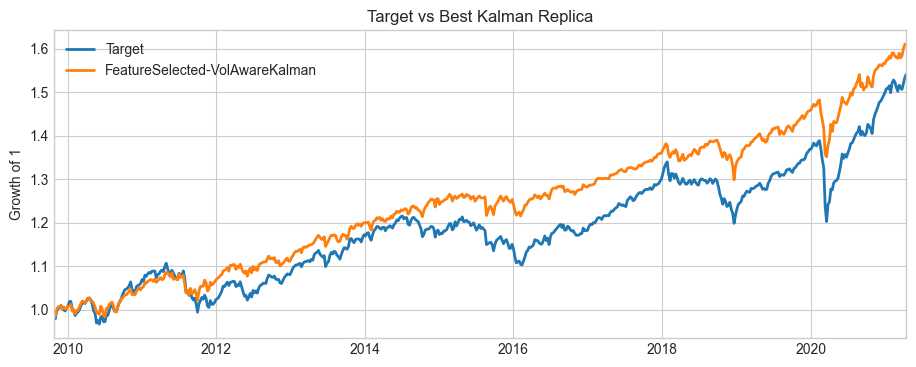

Residual diagnostics


,Model,Residual Mean,Residual Vol Ann.,LB p-value lag5,LB p-value lag10
0,Baseline-Kalman,-0.0000,0.0275,0.0008,0.0017
1,FeatureSelected-VolAwareKalman,0.0001,0.0282,0.0144,0.0055
2,Huberized-Kalman,-0.0000,0.0275,0.0008,0.0017
3,RegimeSwitching-Kalman,-0.0000,0.0275,0.0003,0.0010


Gross vs net accounting summary


,Model,Gross Return,Net Return,Total Cost,Average Turnover,Tracking Error (Net)
0,Baseline-Kalman,0.0377,0.0374,0.0036,0.0119,0.0275
1,FeatureSelected-VolAwareKalman,0.0426,0.0425,0.0018,0.0061,0.0282
2,Huberized-Kalman,0.0377,0.0374,0.0036,0.0119,0.0275
3,RegimeSwitching-Kalman,0.0390,0.0388,0.0023,0.0078,0.0275


Selected futures by model


,Model,Selected Futures
0,Baseline-Kalman,"RX1, TY1, GC1, CO1, ES1, VG1, NQ1, LLL1, TP1, ..."
1,FeatureSelected-VolAwareKalman,"TY1, DU1, ES1, RX1"
2,Huberized-Kalman,"RX1, TY1, GC1, CO1, ES1, VG1, NQ1, LLL1, TP1, ..."
3,RegimeSwitching-Kalman,"RX1, TY1, GC1, CO1, ES1, VG1, NQ1, LLL1, TP1, ..."


Calm/stress regime diagnostics


,Model,Regime,Obs,Tracking Error,Correlation
0,FeatureSelected-VolAwareKalman,calm,552,0.0272,0.8696
1,FeatureSelected-VolAwareKalman,stress,48,0.0380,0.8102
2,RegimeSwitching-Kalman,calm,531,0.0243,0.8944
3,RegimeSwitching-Kalman,stress,69,0.0450,0.7455


Kalman-only reporting checks passed.


In [10]:
kalman_results = [
    {"Family": "Baseline-Kalman", "Result": baseline_kalman_result, "Details": baseline_kalman_details, "Validation TE": validation_tracking_error(baseline_kalman_details), "Spec": baseline_kalman_best_spec},
    {"Family": "FeatureSelected-VolAwareKalman", "Result": feature_selected_vol_kalman_result, "Details": feature_selected_vol_kalman_details, "Validation TE": validation_tracking_error(feature_selected_vol_kalman_details), "Spec": feature_selected_vol_kalman_best_spec},
    {"Family": "Huberized-Kalman", "Result": huber_kalman_result, "Details": huber_kalman_details, "Validation TE": validation_tracking_error(huber_kalman_details), "Spec": huber_kalman_best_spec},
    {"Family": "RegimeSwitching-Kalman", "Result": regime_switch_kalman_result, "Details": regime_switch_kalman_details, "Validation TE": validation_tracking_error(regime_switch_kalman_details), "Spec": regime_switch_kalman_best_spec},
]

summary_rows = []
for item in kalman_results:
    row = dict(item["Result"])
    row["Model Family"] = item["Family"]
    row["Validation TE"] = item["Validation TE"]
    row["Spec"] = str(item["Spec"])
    summary_rows.append(row)

kalman_comparison = pd.DataFrame(summary_rows).sort_values(["Validation TE", "Tracking Error", "Average Turnover"]).reset_index(drop=True)
display(kalman_comparison)
validate_final_summary_columns(kalman_comparison)

winner = kalman_comparison.iloc[0]
winner_family = winner["Model Family"]
winner_pack = [x for x in kalman_results if x["Family"] == winner_family][0]
winner_details = winner_pack["Details"]

print("Final Kalman winner:", winner_family)
print("Winner spec:", winner_pack["Spec"])

aligned = pd.concat([
    winner_details["target"].rename("Target"),
    winner_details["replica"].rename(winner_family),
], axis=1).dropna()
ax = (1 + aligned).cumprod().plot(figsize=(11, 4), linewidth=2)
ax.set_title("Target vs Best Kalman Replica")
ax.set_ylabel("Growth of 1")
plt.show()


def residual_stats(details, label):
    r = (details["replica"] - details["target"]).dropna()
    lb = acorr_ljungbox(r, lags=[5, 10], return_df=True)
    return {
        "Model": label,
        "Residual Mean": float(r.mean()),
        "Residual Vol Ann.": float(r.std() * np.sqrt(ANNUAL_FACTOR)),
        "LB p-value lag5": float(lb.loc[5, "lb_pvalue"]),
        "LB p-value lag10": float(lb.loc[10, "lb_pvalue"]),
    }


def gross_net_row(details, label):
    return {
        "Model": label,
        "Gross Return": annualized_return(details["gross"]),
        "Net Return": annualized_return(details["replica"]),
        "Total Cost": float(details["costs"].sum()),
        "Average Turnover": float(details["turnover"].mean()),
        "Tracking Error (Net)": tracking_error(details["replica"], details["target"]),
    }


def regime_diagnostics(details, label):
    aligned = pd.concat([
        details["replica"].rename("Replica"),
        details["target"].rename("Target"),
        details["vol_regime"].rename("Regime"),
    ], axis=1).dropna()
    if aligned["Regime"].nunique() <= 1:
        return pd.DataFrame()
    rows = []
    for regime, sub in aligned.groupby("Regime"):
        rows.append({
            "Model": label,
            "Regime": regime,
            "Obs": len(sub),
            "Tracking Error": tracking_error(sub["Replica"], sub["Target"]),
            "Correlation": float(sub["Replica"].corr(sub["Target"])),
        })
    return pd.DataFrame(rows).sort_values(["Model", "Regime"])


residual_diagnostics = pd.DataFrame([residual_stats(x["Details"], x["Family"]) for x in kalman_results])
gross_net_summary = pd.DataFrame([gross_net_row(x["Details"], x["Family"]) for x in kalman_results])
selected_futures_summary = pd.DataFrame([
    {"Model": x["Family"], "Selected Futures": ", ".join(x["Details"].get("selected_features", FUTURES_COLUMNS))}
    for x in kalman_results
])
regime_diagnostics_df = pd.concat([regime_diagnostics(x["Details"], x["Family"]) for x in kalman_results], ignore_index=True)

print("Residual diagnostics")
display(residual_diagnostics)
print("Gross vs net accounting summary")
display(gross_net_summary)
print("Selected futures by model")
display(selected_futures_summary)
if not regime_diagnostics_df.empty:
    print("Calm/stress regime diagnostics")
    display(regime_diagnostics_df)

for forbidden in ["best_new_models", "Model1-ConstrainedTE", "Model2-ENetTurnoverL2", "Model5-PCATracking", "PCA Factor Tracking Optimizer", "Rolling Elastic Net"]:
    assert forbidden not in globals(), f"Removed non-Kalman artifact still exists: {forbidden}"

assert set(kalman_comparison["Model Family"]).issubset({"Baseline-Kalman", "FeatureSelected-VolAwareKalman", "Huberized-Kalman", "RegimeSwitching-Kalman"})
print("Kalman-only reporting checks passed.")


## 11) Conclusion

The notebook now compares only Kalman-filter variants. The baseline gives the clean reference implementation, feature-selected volatility-aware Kalman tests whether a smaller futures set and calm/stress noise adaptation improve tracking, Huberized Kalman reduces sensitivity to outliers, and regime-switching Kalman adapts noise without changing the futures universe.

Use `kalman_comparison` as the main leaderboard and inspect the diagnostics tables to understand whether the winner is driven by tracking quality, lower turnover, regime behavior, or risk scaling.
